# Software comparison — prot2exon vs ensembldb / TransVar / Ensembl REST

Three established alternatives are run against the same 5,000-query
stratified set. This notebook loads their per-tool tables and renders
the figure that goes in the paper's Table 1.

See the [Benchmarks wiki page](../wiki/Benchmarks.md) for the full
4-tool table + comparator-specific notes (why each tool, what each
tool's denominator means, the TransVar envelope-only caveat).

## Setup

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import pandas as pd
from pathlib import Path

DATA = Path.home() / "Desktop" / "protein2genomic_data"
V113 = DATA / "validation_v113"     # contains rest_table.tsv + transvar_table.tsv
V86  = DATA / "validation_v86"

assert (V86  / "table1.tsv").exists()
assert (V113 / "rest_table.tsv").exists()
assert (V113 / "transvar_table.tsv").exists()
print("loaded the three external tables")

loaded the three external tables


## 1. Per-tool agreement vs prot2exon

Each external tool answers a slightly different question — we honour the
differences by reporting both the raw exact-match count **and** the
denominator each tool returned data for. (e.g. TransVar ships an older
Ensembl release than our queries reference, so 3,239 / 5,000 fall into
`only_prot2exon` for it — that's annotation drift, not disagreement.)

In [2]:
def _read_external(path: Path) -> pd.Series:
    # Header line starts with a '#' tool tag; skip it.
    df = pd.read_csv(path, sep="\t", comment="#")
    return df.query("category == 'OVERALL'").iloc[0]

ens   = pd.read_csv(V86 / "table1.tsv", sep="\t").query("category == 'OVERALL'").iloc[0]
rest  = _read_external(V113 / "rest_table.tsv")
tvar  = _read_external(V113 / "transvar_table.tsv")

rows = []
for name, r, denom_col in [
    ("ensembldb", ens, "n"),
    ("TransVar", tvar, "exact_match"),
    ("Ensembl REST", rest, "n"),
]:
    # both-returned denominator: exact + off_by_one + structural
    both = r["exact_match"] + r["off_by_one"] + r["structural_mismatch"]
    if name == "TransVar":
        # TransVar's intersection denominator is documented as 1,761 — the
        # queries where TransVar has the ENST in its bundled annotation.
        # exact_match alone gives us that.
        denom = both
    else:
        denom = r["n"] if name == "ensembldb" else both
    pct = 100 * r["exact_match"] / max(1, denom)
    rows.append({"tool": name, "exact_match": int(r["exact_match"]),
                 "denominator": int(denom), "exact_pct": pct,
                 "off_by_one": int(r["off_by_one"]),
                 "only_prot2exon": int(r["only_prot2exon"])})
agree = pd.DataFrame(rows)
agree

,tool,exact_match,denominator,exact_pct,off_by_one,only_prot2exon
0,ensembldb,5000,5000,100.0,0,0
1,TransVar,1761,1761,100.0,0,3239
2,Ensembl REST,983,1000,98.3,17,0


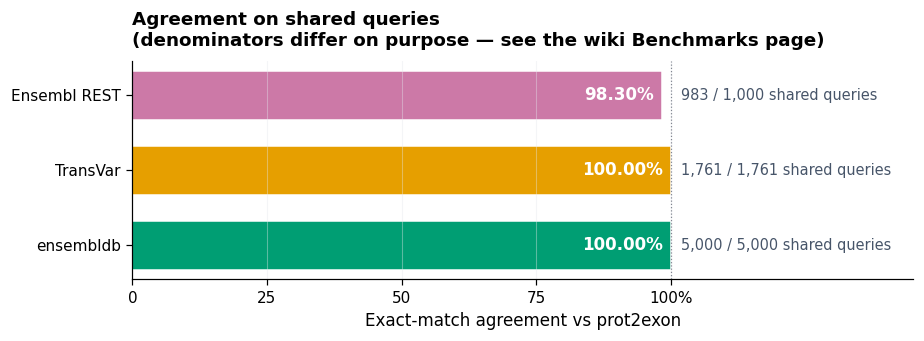

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 3.2))
palette = [COLORS['ensembldb'], COLORS['transvar'], COLORS['rest']]
bars = ax.barh(agree["tool"], agree["exact_pct"],
               color=palette, edgecolor="white", height=0.65)
for b, r in zip(bars, agree.itertuples()):
    ax.text(102, b.get_y() + b.get_height()/2,
            f"{r.exact_match:,} / {r.denominator:,} shared queries",
            va="center", fontsize=9.5, color="#475569")
    ax.text(r.exact_pct - 1.5, b.get_y() + b.get_height()/2,
            f"{r.exact_pct:.2f}%", va="center", ha="right",
            fontsize=11, fontweight="semibold", color="white")
ax.set_xlim(0, 145)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0", "25", "50", "75", "100%"])
ax.axvline(100, ls=":", color="#0f172a", lw=0.8, alpha=0.5)
ax.set_xlabel("Exact-match agreement vs prot2exon")
ax.set_title("Agreement on shared queries\n"
             "(denominators differ on purpose — see the wiki Benchmarks page)",
             loc='left')
ax.grid(axis='x', alpha=0.4, lw=0.7); ax.grid(axis='y', visible=False)
fig.tight_layout()
plt.show()

## 2. Throughput at N = 10,000

The 4-tool runtime side. Numbers below are from the scaling benchmark
(see the next notebook for the raw scaling table).

In [4]:
# Headline numbers from benchmarks/README.md / wiki:Benchmarks.
runtime = pd.DataFrame([
    {"tool": "prot2exon",   "wall_s": 1.71,    "throughput_qps": 5847,  "rss_mb": 788},
    {"tool": "ensembldb",   "wall_s": 1558.0,  "throughput_qps": 6,     "rss_mb": 1252},
    {"tool": "TransVar",    "wall_s": 7.54,    "throughput_qps": 1326,  "rss_mb": 284},
    {"tool": "Ensembl REST","wall_s": 9180.0,  "throughput_qps": 1.09,  "rss_mb": float('nan')},
])
runtime

,tool,wall_s,throughput_qps,rss_mb
0,prot2exon,1.71,5847.00,788.0
1,ensembldb,1558.00,6.00,1252.0
2,TransVar,7.54,1326.00,284.0
3,Ensembl REST,9180.00,1.09,NaN


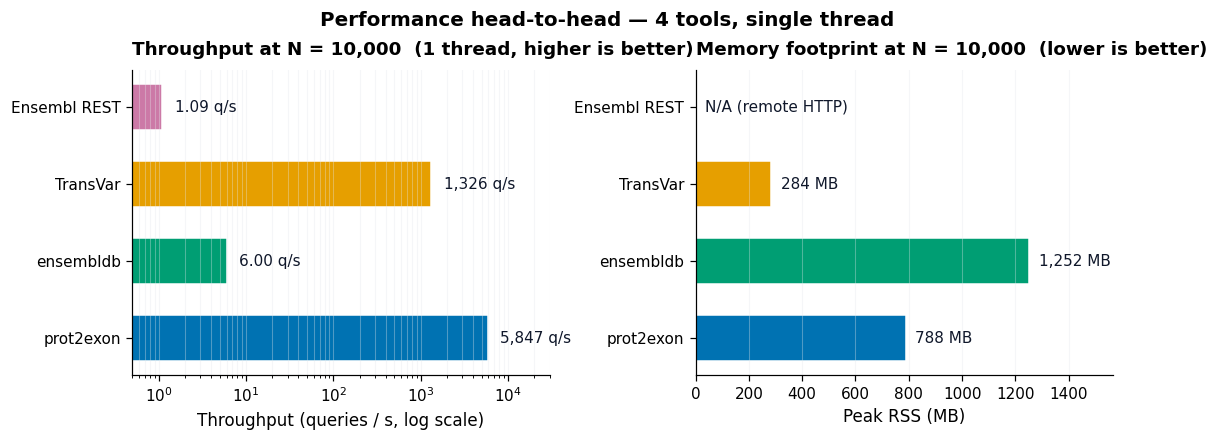

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6),
                         gridspec_kw={'wspace': 0.35})
tool_colors = [COLORS['prot2exon'], COLORS['ensembldb'],
               COLORS['transvar'],   COLORS['rest']]

# --- Throughput (log scale so 5,847 q/s and 1.09 q/s share an axis) ---
axes[0].barh(runtime["tool"], runtime["throughput_qps"],
             color=tool_colors, edgecolor="white", height=0.6)
axes[0].set_xscale("log")
axes[0].set_xlabel("Throughput (queries / s, log scale)")
axes[0].set_title("Throughput at N = 10,000  (1 thread, higher is better)",
                  loc='left')
for i, v in enumerate(runtime["throughput_qps"]):
    label = f"{v:,.0f} q/s" if v >= 10 else f"{v:.2f} q/s"
    axes[0].text(v * 1.4, i, label, va="center", fontsize=10, color="#0f172a")
axes[0].set_xlim(0.5, 30_000)
axes[0].grid(axis='x', which='both', alpha=0.35, lw=0.7); axes[0].grid(axis='y', visible=False)

# --- Peak RSS ---
rss = runtime["rss_mb"].fillna(0)
axes[1].barh(runtime["tool"], rss,
             color=tool_colors, edgecolor="white", height=0.6)
axes[1].set_xlabel("Peak RSS (MB)")
axes[1].set_title("Memory footprint at N = 10,000  (lower is better)",
                  loc='left')
for i, v in enumerate(rss):
    txt = f"{int(v):,} MB" if v > 0 else "N/A (remote HTTP)"
    axes[1].text(v + 35, i, txt, va="center", fontsize=10, color="#0f172a")
axes[1].set_xlim(0, max(rss) * 1.25)
axes[1].grid(axis='x', alpha=0.35, lw=0.7); axes[1].grid(axis='y', visible=False)

fig.suptitle("Performance head-to-head — 4 tools, single thread",
             fontsize=13, fontweight="semibold", y=1.03)
plt.show()

## What this tells you

- **prot2exon is ~900× faster than ensembldb** at N = 10,000 — same intervals, smaller index.
- **~4.4× faster than TransVar** with no FASTA bundle required.
- **~5,400× faster than Ensembl REST** — REST is HTTP-bound, not rate-limited at the cap; the canonical pattern is what users actually write.
- **prot2exon and ensembldb agree on 100% of the 5,000 queries**; TransVar agrees on the 1,761 / 5,000 it has annotation for; REST agrees on 983 / 1,000 (17 off-by-ones, zero structural).
- The other three tools all return the **genomic envelope only**; prot2exon is the only one that returns the per-CDS-exon decomposition the wiki's [Output modes](../wiki/Output-modes.md) describes.